# Dual-Path Fake News Classifier — Full Pipeline

**Dataset**: fake 5,754 · real 17,441 → ~1:3 imbalance  
**Imbalance fixes**: `class_weight='balanced'` · SMOTE · threshold tuning · macro F1 evaluation

```
Input text
  ├── PATH A → TF-IDF → LR + RF + SVM (balanced) → Meta LR → threshold → Output A
  └── PATH B → BERT CLS embed → LR head (balanced) → threshold          → Output B
```

**Evaluation metrics**: Confusion Matrix · ROC-AUC · PR-AUC · Threshold Sweep · Calibration · MCC · Cohen's Kappa · Brier · Log-loss · Full Heatmap · Dashboard

---
# 1. Install Dependencies

In [ ]:
!pip install -q transformers torch scikit-learn imbalanced-learn pandas numpy tqdm matplotlib seaborn

# 2. Imports

In [ ]:
import re, os, zipfile, warnings
import numpy as np
import pandas as pd
import torch
import warnings
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

warnings.filterwarnings('ignore')

from tqdm import tqdm

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC

from sklearn.metrics import (
    classification_report, f1_score, accuracy_score,
    confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score,
    matthews_corrcoef, cohen_kappa_score,
    brier_score_loss,
    log_loss, roc_auc_score
)

# ✅ FIXED IMPORT (IMPORTANT)
from sklearn.calibration import calibration_curve

from imblearn.over_sampling import SMOTE
from transformers import AutoTokenizer, AutoModel
from matplotlib.colors import LinearSegmentedColormap

DEVICE = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {DEVICE}')

# ── Professional dark theme ──────────────────────────────────────────────────
plt.rcParams.update({
    'figure.facecolor' : '#0D1117',
    'axes.facecolor'   : '#161B22',
    'axes.edgecolor'   : '#30363D',
    'axes.labelcolor'  : '#C9D1D9',
    'axes.titlecolor'  : '#F0F6FC',
    'axes.titlesize'   : 13,
    'axes.labelsize'   : 11,
    'axes.grid'        : True,
    'grid.color'       : '#21262D',
    'grid.linewidth'   : 0.6,
    'xtick.color'      : '#8B949E',
    'ytick.color'      : '#8B949E',
    'text.color'       : '#C9D1D9',
    'legend.facecolor' : '#161B22',
    'legend.edgecolor' : '#30363D',
    'legend.fontsize'  : 10,
    'font.family'      : 'DejaVu Sans',
    'figure.dpi'       : 140,
    'savefig.dpi'      : 180,
    'savefig.facecolor': '#0D1117',
})

C_STACK  = '#58A6FF'
C_BERT   = '#3FB950'
C_CHANCE = '#6E7681'
C_FAKE   = '#F85149'
C_REAL   = '#58A6FF'
LABELS   = ['Real', 'Fake']

print('Imports OK.')

Device: cuda
Imports OK.


---
# 3. Load Dataset

In [ ]:
df = pd.read_csv('fake_news_final_dataset (1).csv')
df = df[df['final_text'].notna() & (df['final_text'].str.strip() != '')].reset_index(drop=True)

X = df['final_text'].astype(str).tolist()
y = df['label'].tolist()

print(f'Total rows      : {len(df)}')
print(f'Fake (1)        : {sum(y)}')
print(f'Real (0)        : {len(y) - sum(y)}')
print(f'Imbalance ratio : 1 : {(len(y)-sum(y)) / sum(y):.1f}')

Total rows      : 8703
Fake (1)        : 2160
Real (0)        : 6543
Imbalance ratio : 1 : 3.0


---
# 4. Train / Val / Test Split

In [ ]:
X_train, X_temp, y_train, y_temp = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)
X_val, X_test, y_val, y_test = train_test_split(
    X_temp, y_temp, test_size=0.50, random_state=42, stratify=y_temp
)

y_train = np.array(y_train)
y_val   = np.array(y_val)
y_test  = np.array(y_test)

print(f'Train : {len(X_train)}  |  Val : {len(X_val)}  |  Test : {len(X_test)}')
print(f'Train fake / real : {y_train.sum()} / {(y_train==0).sum()}')

Train : 6092  |  Val : 1305  |  Test : 1306
Train fake / real : 1512 / 4580


---
# PATH A — Stacked Classifier (LR + RF + SVM)

## A1. TF-IDF + SMOTE

In [ ]:
tfidf = TfidfVectorizer(max_features=50000, ngram_range=(1, 2), sublinear_tf=True)
X_train_tfidf = tfidf.fit_transform(X_train)
X_val_tfidf   = tfidf.transform(X_val)
X_test_tfidf  = tfidf.transform(X_test)

smote = SMOTE(random_state=42)
X_train_sm, y_train_sm = smote.fit_resample(X_train_tfidf, y_train)
print(f'After SMOTE — fake: {y_train_sm.sum()}  real: {(y_train_sm==0).sum()}')

After SMOTE — fake: 4580  real: 4580


## A2. Base Models

In [ ]:
lr = LogisticRegression(max_iter=1000, C=5.0, class_weight='balanced', solver='lbfgs', n_jobs=-1)
lr.fit(X_train_sm, y_train_sm)
lr_val_prob  = lr.predict_proba(X_val_tfidf)[:, 1]
lr_test_prob = lr.predict_proba(X_test_tfidf)[:, 1]
print('LR  accuracy:', accuracy_score(y_test, lr.predict(X_test_tfidf)))

rf = RandomForestClassifier(n_estimators=300, class_weight='balanced', n_jobs=-1, random_state=42)
rf.fit(X_train_sm, y_train_sm)
rf_val_prob  = rf.predict_proba(X_val_tfidf)[:, 1]
rf_test_prob = rf.predict_proba(X_test_tfidf)[:, 1]
print('RF  accuracy:', accuracy_score(y_test, rf.predict(X_test_tfidf)))

svm = SVC(kernel='linear', probability=True, C=1.0, class_weight='balanced')
svm.fit(X_train_sm, y_train_sm)
svm_val_prob  = svm.predict_proba(X_val_tfidf)[:, 1]
svm_test_prob = svm.predict_proba(X_test_tfidf)[:, 1]
print('SVM accuracy:', accuracy_score(y_test, svm.predict(X_test_tfidf)))

LR  accuracy: 0.8797856049004594
RF  accuracy: 0.8575803981623277
SVM accuracy: 0.8767228177641654


## A3. Meta-Learner

In [ ]:
X_meta_val  = np.column_stack([lr_val_prob,  rf_val_prob,  svm_val_prob])
X_meta_test = np.column_stack([lr_test_prob, rf_test_prob, svm_test_prob])

meta_stack = LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced')
meta_stack.fit(X_meta_val, y_val)

stack_prob     = meta_stack.predict_proba(X_meta_test)[:, 1]
stack_val_prob = meta_stack.predict_proba(X_meta_val)[:, 1]

## A4. Threshold Tuning

In [ ]:
best_thresh_a, best_f1_a = 0.5, 0.0
for t in np.arange(0.20, 0.80, 0.01):
    preds = (stack_val_prob >= t).astype(int)
    f1 = f1_score(y_val, preds, average='macro')
    if f1 > best_f1_a:
        best_f1_a, best_thresh_a = f1, t

stack_pred = (stack_prob >= best_thresh_a).astype(int)

print(f'Best threshold (Path A): {best_thresh_a:.2f}')
print('=' * 48)
print('OUTPUT A — Stacked Model (LR + RF + SVM)')
print('=' * 48)
print(classification_report(y_test, stack_pred, target_names=['Real', 'Fake'], digits=4))

Best threshold (Path A): 0.67
OUTPUT A — Stacked Model (LR + RF + SVM)
              precision    recall  f1-score   support

        Real     0.9444    0.8992    0.9212       982
        Fake     0.7332    0.8395    0.7827       324

    accuracy                         0.8844      1306
   macro avg     0.8388    0.8693    0.8520      1306
weighted avg     0.8920    0.8844    0.8869      1306



---
# PATH B — BERT Classifier (Independent)

## B1. BERT Embeddings

In [ ]:
BERT_MODEL = 'bert-base-uncased'
MAX_LEN    = 256
BATCH_SIZE = 32

tokenizer = AutoTokenizer.from_pretrained(BERT_MODEL)
bert      = AutoModel.from_pretrained(BERT_MODEL).to(DEVICE)
bert.eval()

def get_bert_embeddings(texts: list) -> np.ndarray:
    all_embs = []
    for i in tqdm(range(0, len(texts), BATCH_SIZE), desc='BERT'):
        batch = texts[i: i + BATCH_SIZE]
        enc = tokenizer(
            batch, padding=True, truncation=True,
            max_length=MAX_LEN, return_tensors='pt'
        ).to(DEVICE)
        with torch.no_grad():
            out = bert(**enc)
        all_embs.append(out.last_hidden_state[:, 0, :].cpu().numpy())
    return np.vstack(all_embs)

X_train_bert = get_bert_embeddings(X_train)
X_val_bert   = get_bert_embeddings(X_val)
X_test_bert  = get_bert_embeddings(X_test)
print('BERT shape:', X_train_bert.shape)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt: 0.00B [00:00, ?B/s]

tokenizer.json: 0.00B [00:00, ?B/s]

model.safetensors:   0%|          | 0.00/440M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.
BERT: 100%|██████████| 41/41 [00:21<00:00,  1.88it/s]

BERT shape: (6092, 768)


## B2. SMOTE + Classification Head

In [ ]:
X_train_bert_sm, y_train_bert_sm = smote.fit_resample(X_train_bert, y_train)
print(f'BERT SMOTE — fake: {y_train_bert_sm.sum()}  real: {(y_train_bert_sm==0).sum()}')

bert_clf = LogisticRegression(max_iter=1000, C=1.0, class_weight='balanced', solver='lbfgs')
bert_clf.fit(X_train_bert_sm, y_train_bert_sm)

bert_prob     = bert_clf.predict_proba(X_test_bert)[:, 1]
bert_val_prob = bert_clf.predict_proba(X_val_bert)[:, 1]

BERT SMOTE — fake: 4580  real: 4580


## B3. Threshold Tuning

In [ ]:
best_thresh_b, best_f1_b = 0.5, 0.0
for t in np.arange(0.20, 0.80, 0.01):
    preds = (bert_val_prob >= t).astype(int)
    f1 = f1_score(y_val, preds, average='macro')
    if f1 > best_f1_b:
        best_f1_b, best_thresh_b = f1, t

bert_pred = (bert_prob >= best_thresh_b).astype(int)

print(f'Best threshold (Path B): {best_thresh_b:.2f}')
print('=' * 48)
print('OUTPUT B — BERT Classifier')
print('=' * 48)
print(classification_report(y_test, bert_pred, target_names=['Real', 'Fake'], digits=4))

Best threshold (Path B): 0.70
OUTPUT B — BERT Classifier
              precision    recall  f1-score   support

        Real     0.9005    0.9216    0.9109       982
        Fake     0.7442    0.6914    0.7168       324

    accuracy                         0.8645      1306
   macro avg     0.8223    0.8065    0.8139      1306
weighted avg     0.8617    0.8645    0.8628      1306



---
# 5. Quick Comparison Table

In [ ]:
def quick_metrics(y_true, y_pred):
    return {
        'Accuracy' : f'{accuracy_score(y_true, y_pred)*100:.2f}%',
        'Macro F1' : f'{f1_score(y_true, y_pred, average="macro")*100:.2f}%',
        'Fake F1'  : f'{f1_score(y_true, y_pred, pos_label=1)*100:.2f}%',
        'Real F1'  : f'{f1_score(y_true, y_pred, pos_label=0)*100:.2f}%',
    }

results = pd.DataFrame([
    {'Model': 'LR (base)',  **quick_metrics(y_test, lr.predict(X_test_tfidf))},
    {'Model': 'RF (base)',  **quick_metrics(y_test, rf.predict(X_test_tfidf))},
    {'Model': 'SVM (base)', **quick_metrics(y_test, svm.predict(X_test_tfidf))},
    {'Model': 'Stack  (A)', **quick_metrics(y_test, stack_pred)},
    {'Model': 'BERT   (B)', **quick_metrics(y_test, bert_pred)},
])
print(results.to_string(index=False))

     Model Accuracy Macro F1 Fake F1 Real F1
 LR (base)   87.98%   84.99%  78.28%  91.69%
 RF (base)   85.76%   82.98%  76.09%  89.86%
SVM (base)   87.67%   84.68%  77.91%  91.45%
Stack  (A)   88.44%   85.20%  78.27%  92.12%
BERT   (B)   86.45%   81.39%  71.68%  91.09%


---
# 6. Save Models

In [ ]:
import joblib
joblib.dump(tfidf,      'tfidf_vectorizer.pkl')
joblib.dump(lr,         'model_lr.pkl')
joblib.dump(rf,         'model_rf.pkl')
joblib.dump(svm,        'model_svm.pkl')
joblib.dump(meta_stack, 'model_meta_stack.pkl')
joblib.dump(bert_clf,   'model_bert_head.pkl')
joblib.dump({'thresh_a': best_thresh_a, 'thresh_b': best_thresh_b}, 'thresholds.pkl')
print('All models saved.')

All models saved.


---
# 7. Evaluation Metrics
## 7.1 Helper Functions

In [ ]:
def plot_confusion(ax, y_true, y_pred, title, color):
    cm = confusion_matrix(y_true, y_pred)
    cm_pct = cm.astype(float) / cm.sum(axis=1, keepdims=True) * 100
    annot = np.array([
        [f'{cm[i,j]}\n({cm_pct[i,j]:.1f}%)' for j in range(2)]
        for i in range(2)
    ])
    cmap = LinearSegmentedColormap.from_list('cm', ['#161B22', color], N=256)
    sns.heatmap(
        cm_pct, annot=annot, fmt='', cmap=cmap,
        linewidths=1.5, linecolor='#0D1117',
        xticklabels=LABELS, yticklabels=LABELS,
        ax=ax, vmin=0, vmax=100,
        annot_kws={'size': 12, 'weight': 'bold', 'color': '#F0F6FC'},
        cbar_kws={'shrink': 0.75, 'pad': 0.02}
    )
    ax.set_title(title, pad=14, fontsize=13, color='#F0F6FC', fontweight='bold')
    ax.set_ylabel('True label', labelpad=10)
    ax.set_xlabel('Predicted label', labelpad=10)
    ax.tick_params(colors='#8B949E', length=0)
    ax.collections[0].colorbar.ax.tick_params(colors='#8B949E')
    ax.collections[0].colorbar.set_label('% of true class', color='#8B949E', fontsize=9)
    for i in range(2):
        ax.add_patch(plt.Rectangle((i, i), 1, 1, fill=False,
                                   edgecolor='#F0F6FC', lw=2, zorder=5))


def threshold_sweep(y_true, probs, color, title, ax):
    thresholds = np.arange(0.05, 0.96, 0.01)
    f1s, precs, recs, accs = [], [], [], []
    for t in thresholds:
        p = (probs >= t).astype(int)
        f1s.append(f1_score(y_true, p, average='macro', zero_division=0))
        precs.append(f1_score(y_true, p, pos_label=1, average='binary', zero_division=0))
        recs.append(sum((p==1) & (y_true==1)) / max(sum(y_true==1), 1))
        accs.append(accuracy_score(y_true, p))
    best_t = thresholds[np.argmax(f1s)]
    ax.plot(thresholds, f1s,   color=color,    lw=2,   label='Macro F1')
    ax.plot(thresholds, precs, color='#F85149', lw=1.5, ls='--', label='Fake Precision')
    ax.plot(thresholds, recs,  color='#E3B341', lw=1.5, ls='--', label='Fake Recall')
    ax.plot(thresholds, accs,  color='#8B949E', lw=1.2, ls=':',  label='Accuracy')
    ax.axvline(best_t, color='#F0F6FC', lw=1, ls='--')
    ax.text(best_t+0.01, 0.15, f'best={best_t:.2f}', fontsize=8, color='#F0F6FC')
    ax.set_title(title, fontsize=12, color='#F0F6FC', fontweight='bold')
    ax.set_xlabel('Decision threshold')
    ax.set_ylabel('Score')
    ax.set_ylim([0, 1.05])
    ax.legend(fontsize=8, loc='upper right')


def full_metrics(y_true, y_pred, y_prob, name):
    cm = confusion_matrix(y_true, y_pred)
    tn, fp, fn, tp = cm.ravel()
    return {
        'Model'          : name,
        'Accuracy'       : accuracy_score(y_true, y_pred),
        'Macro F1'       : f1_score(y_true, y_pred, average='macro'),
        'Weighted F1'    : f1_score(y_true, y_pred, average='weighted'),
        'Fake Precision' : tp / max(tp+fp, 1),
        'Fake Recall'    : tp / max(tp+fn, 1),
        'Fake F1'        : f1_score(y_true, y_pred, pos_label=1),
        'Real Precision' : tn / max(tn+fn, 1),
        'Real Recall'    : tn / max(tn+fp, 1),
        'Real F1'        : f1_score(y_true, y_pred, pos_label=0),
        'Specificity'    : tn / max(tn+fp, 1),
        'Sensitivity'    : tp / max(tp+fn, 1),
        'FPR'            : fp / max(fp+tn, 1),
        'FNR'            : fn / max(fn+tp, 1),
        'ROC AUC'        : roc_auc_score(y_true, y_prob),
        'Avg Precision'  : average_precision_score(y_true, y_prob),
        'Brier Score'    : brier_score_loss(y_true, y_prob),
        'Log Loss'       : log_loss(y_true, y_prob),
        'MCC'            : matthews_corrcoef(y_true, y_pred),
        "Cohen's Kappa"  : cohen_kappa_score(y_true, y_pred),
    }

print('Helper functions defined.')

Helper functions defined.


## 7.2 Confusion Matrices

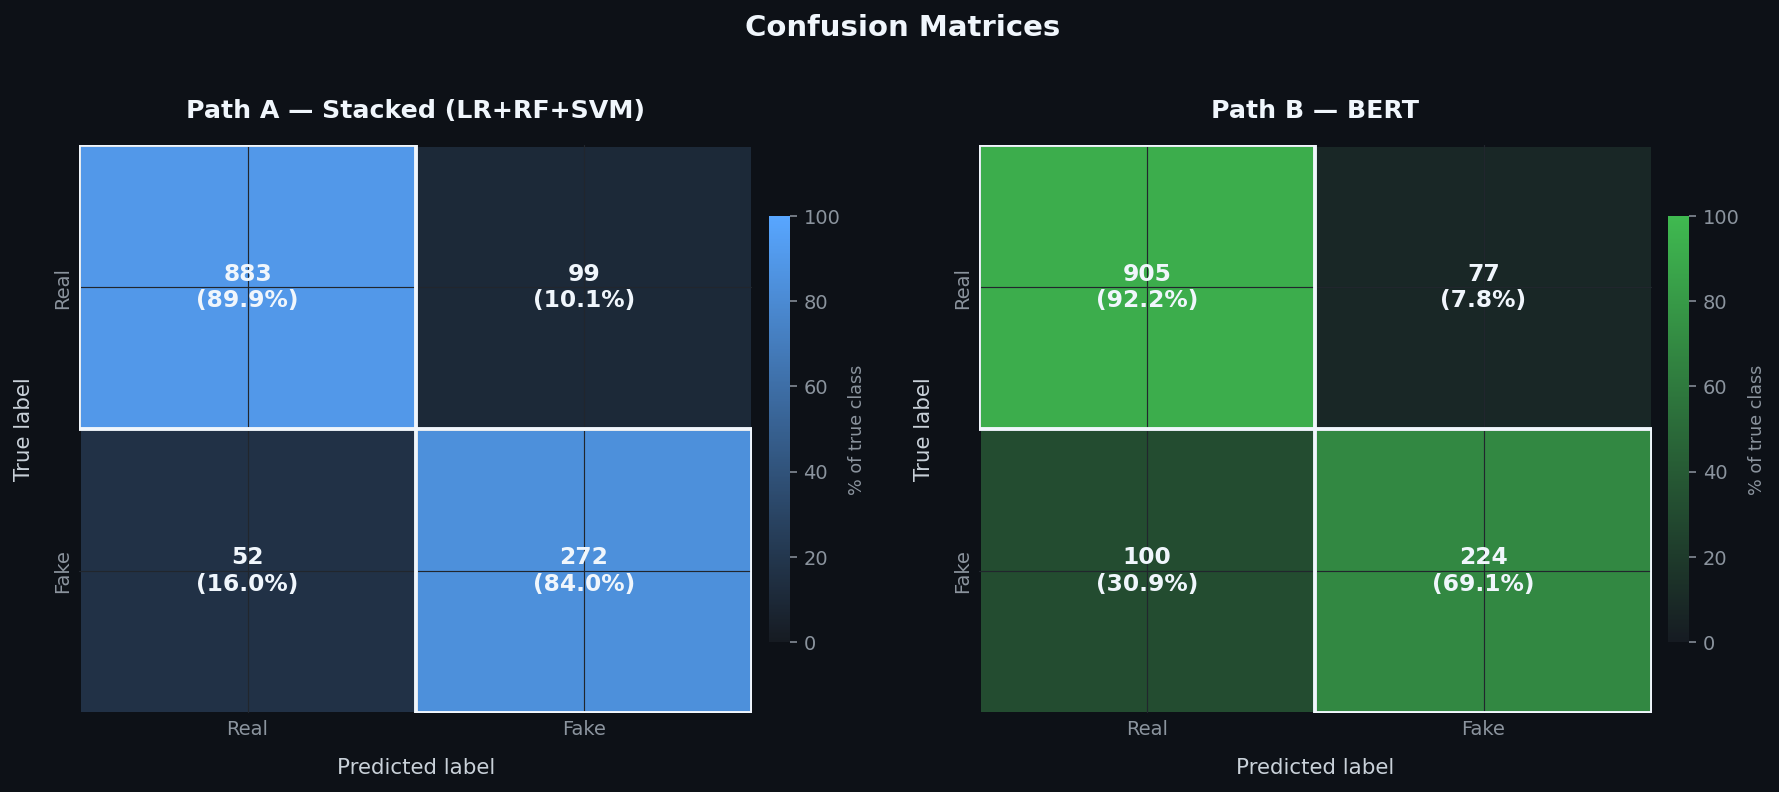

In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle('Confusion Matrices', fontsize=15, color='#F0F6FC', fontweight='bold', y=1.02)
plot_confusion(axes[0], y_test, stack_pred, 'Path A — Stacked (LR+RF+SVM)', C_STACK)
plot_confusion(axes[1], y_test, bert_pred,  'Path B — BERT',                C_BERT)
plt.tight_layout()
plt.savefig('confusion_matrices.png', bbox_inches='tight')
plt.show()

## 7.3 ROC Curves + AUC

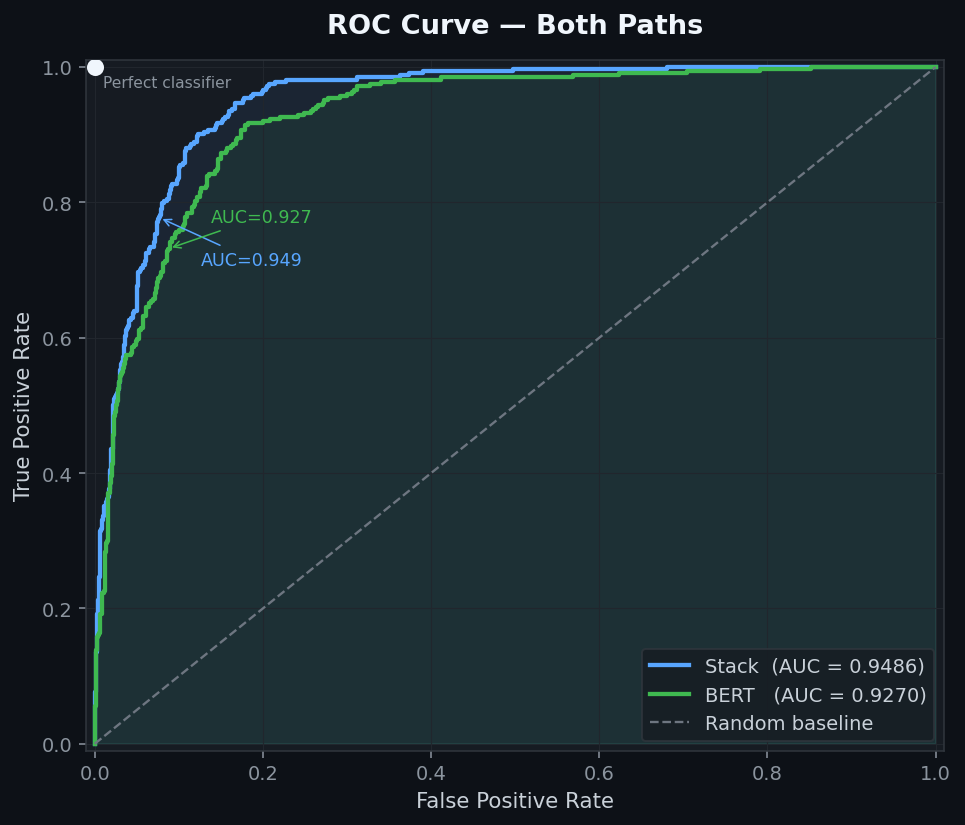

In [ ]:
fpr_a, tpr_a, _ = roc_curve(y_test, stack_prob)
fpr_b, tpr_b, _ = roc_curve(y_test, bert_prob)
auc_a = auc(fpr_a, tpr_a)
auc_b = auc(fpr_b, tpr_b)

fig, ax = plt.subplots(figsize=(7, 6))
ax.fill_between(fpr_a, tpr_a, alpha=0.08, color=C_STACK)
ax.fill_between(fpr_b, tpr_b, alpha=0.08, color=C_BERT)
ax.plot(fpr_a, tpr_a, color=C_STACK, lw=2.2, label=f'Stack  (AUC = {auc_a:.4f})')
ax.plot(fpr_b, tpr_b, color=C_BERT,  lw=2.2, label=f'BERT   (AUC = {auc_b:.4f})')
ax.plot([0,1], [0,1], '--', color=C_CHANCE, lw=1.2, label='Random baseline')
mid_a = len(fpr_a) // 2
mid_b = len(fpr_b) // 2
ax.annotate(f'AUC={auc_a:.3f}', xy=(fpr_a[mid_a], tpr_a[mid_a]), fontsize=9, color=C_STACK,
            xytext=(fpr_a[mid_a]+0.05, tpr_a[mid_a]-0.07),
            arrowprops=dict(arrowstyle='->', color=C_STACK, lw=0.8))
ax.annotate(f'AUC={auc_b:.3f}', xy=(fpr_b[mid_b], tpr_b[mid_b]), fontsize=9, color=C_BERT,
            xytext=(fpr_b[mid_b]+0.05, tpr_b[mid_b]+0.04),
            arrowprops=dict(arrowstyle='->', color=C_BERT, lw=0.8))
ax.set_title('ROC Curve — Both Paths', fontsize=14, fontweight='bold', color='#F0F6FC', pad=14)
ax.set_xlabel('False Positive Rate')
ax.set_ylabel('True Positive Rate')
ax.set_xlim([-0.01, 1.01]); ax.set_ylim([-0.01, 1.01])
ax.legend(loc='lower right')
ax.scatter([0], [1], s=60, color='#F0F6FC', zorder=5)
ax.annotate('Perfect classifier', xy=(0.01, 0.97), fontsize=8, color='#8B949E')
plt.tight_layout()
plt.savefig('roc_curves.png', bbox_inches='tight')
plt.show()

## 7.4 Precision-Recall Curves + AP

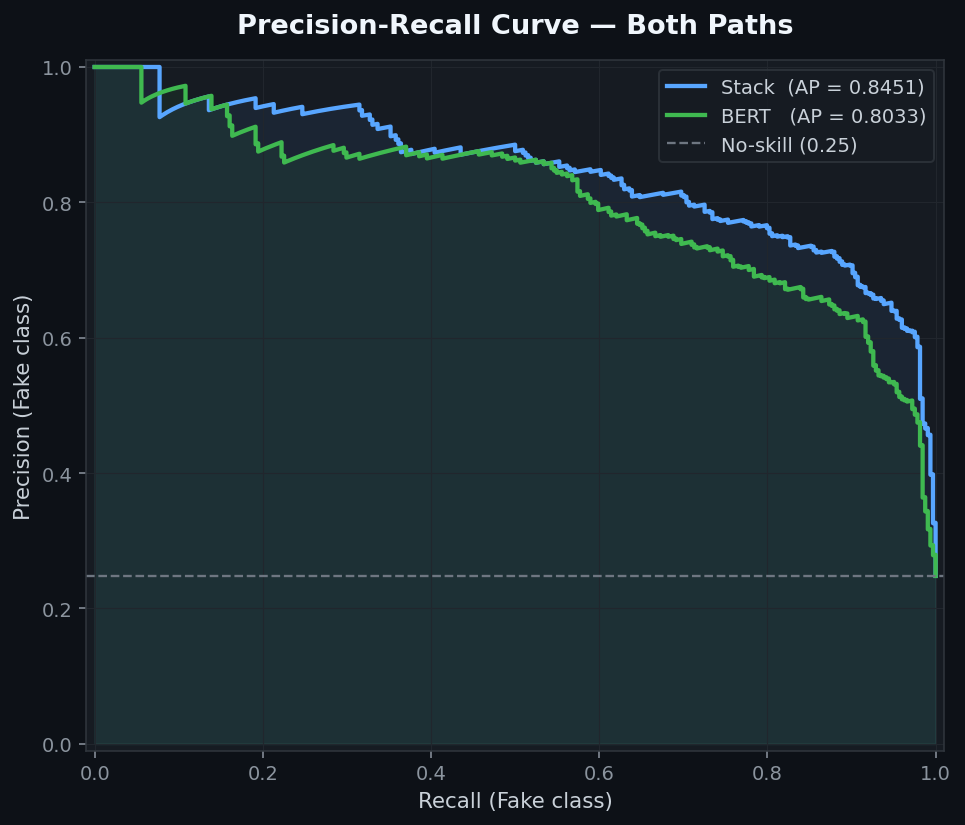

In [22]:
prec_a, rec_a, _ = precision_recall_curve(y_test, stack_prob)
prec_b, rec_b, _ = precision_recall_curve(y_test, bert_prob)
ap_a = average_precision_score(y_test, stack_prob)
ap_b = average_precision_score(y_test, bert_prob)
baseline_pr = y_test.mean()

fig, ax = plt.subplots(figsize=(7, 6))
ax.fill_between(rec_a, prec_a, alpha=0.08, color=C_STACK)
ax.fill_between(rec_b, prec_b, alpha=0.08, color=C_BERT)
ax.plot(rec_a, prec_a, color=C_STACK, lw=2.2, label=f'Stack  (AP = {ap_a:.4f})')
ax.plot(rec_b, prec_b, color=C_BERT,  lw=2.2, label=f'BERT   (AP = {ap_b:.4f})')
ax.axhline(baseline_pr, color=C_CHANCE, lw=1.2, ls='--', label=f'No-skill ({baseline_pr:.2f})')
ax.set_title('Precision-Recall Curve — Both Paths', fontsize=14,
             fontweight='bold', color='#F0F6FC', pad=14)
ax.set_xlabel('Recall (Fake class)')
ax.set_ylabel('Precision (Fake class)')
ax.set_xlim([-0.01, 1.01]); ax.set_ylim([-0.01, 1.01])
ax.legend(loc='upper right')
plt.tight_layout()
plt.savefig('pr_curves.png', bbox_inches='tight')
plt.show()

## 7.5 Threshold Sensitivity Sweep

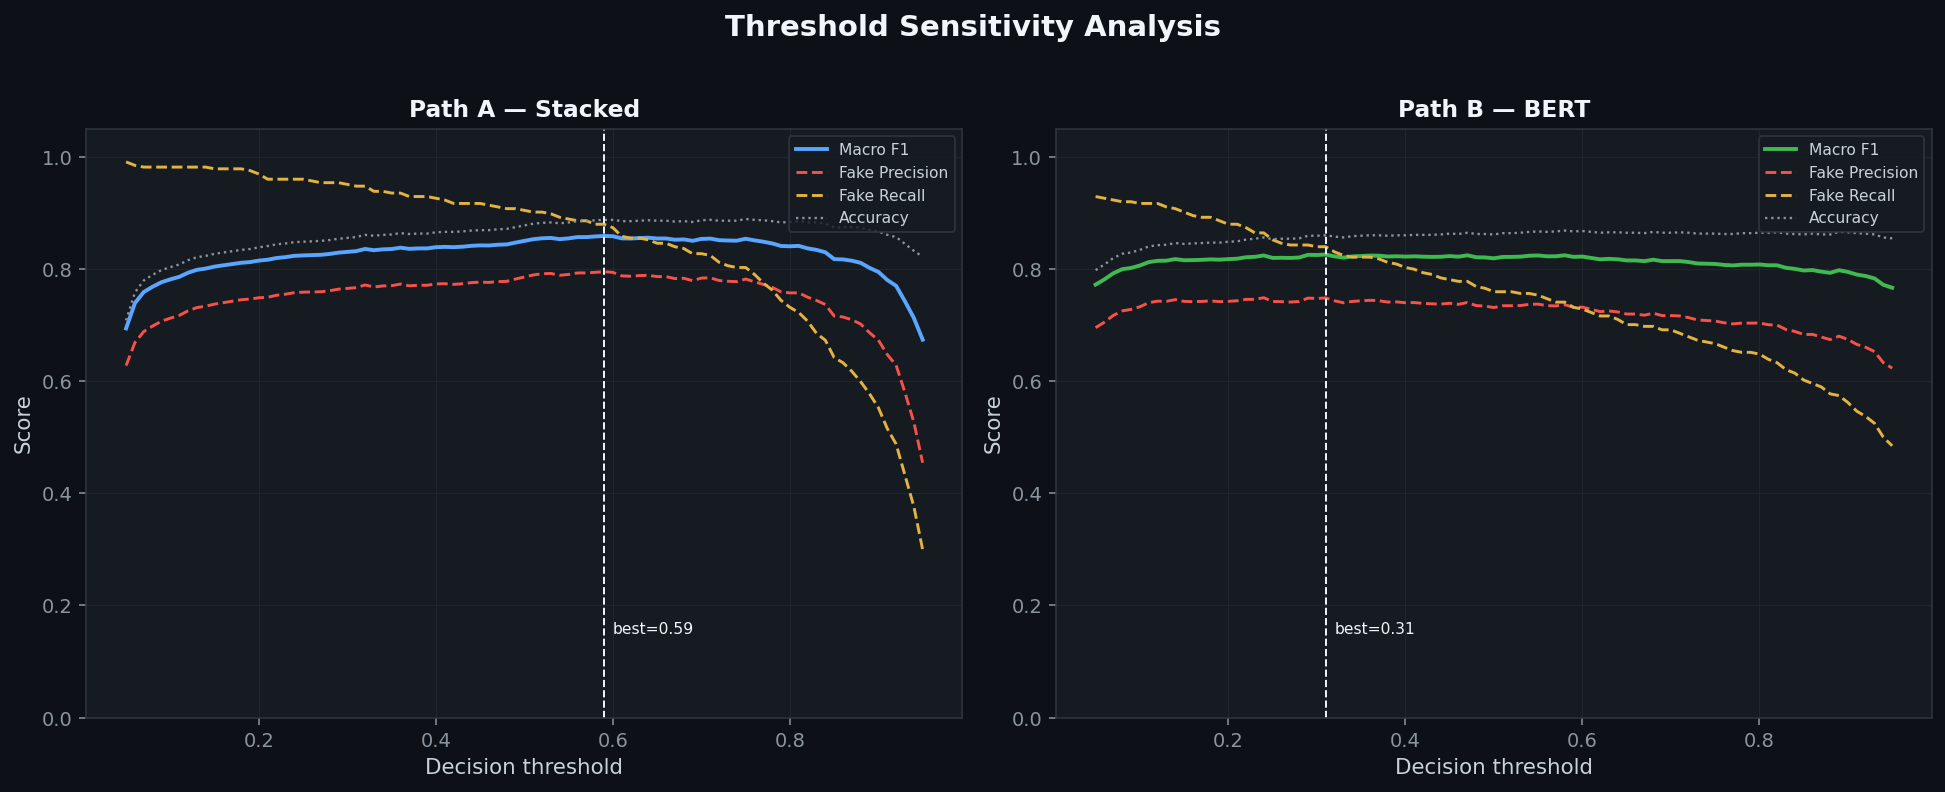

In [23]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5.5))
fig.suptitle('Threshold Sensitivity Analysis', fontsize=15,
             color='#F0F6FC', fontweight='bold', y=1.02)
threshold_sweep(y_test, stack_prob, C_STACK, 'Path A — Stacked', axes[0])
threshold_sweep(y_test, bert_prob,  C_BERT,  'Path B — BERT',    axes[1])
plt.tight_layout()
plt.savefig('threshold_sweep.png', bbox_inches='tight')
plt.show()

## 7.6 Calibration Curves

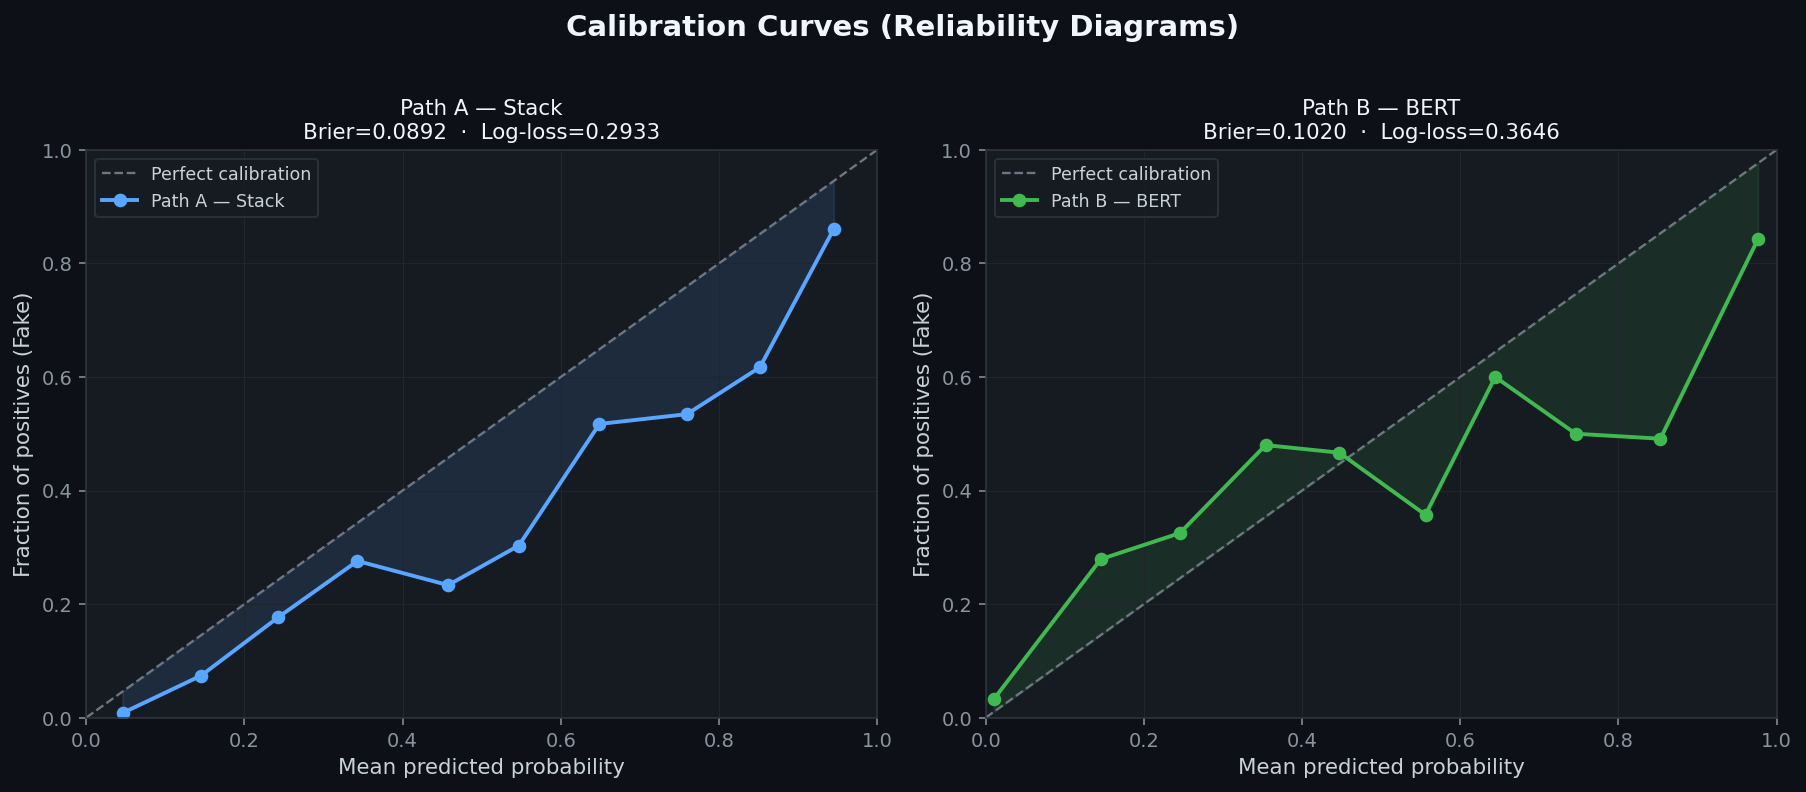

In [24]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5.5))
fig.suptitle('Calibration Curves (Reliability Diagrams)', fontsize=15,
             color='#F0F6FC', fontweight='bold', y=1.02)
for ax, probs, color, label in [
    (axes[0], stack_prob, C_STACK, 'Path A — Stack'),
    (axes[1], bert_prob,  C_BERT,  'Path B — BERT'),
]:
    fp_, mp_ = calibration_curve(y_test, probs, n_bins=10)
    brier_ = brier_score_loss(y_test, probs)
    ll_    = log_loss(y_test, probs)
    ax.fill_between(mp_, fp_, mp_, alpha=0.12, color=color)
    ax.plot([0,1],[0,1],'--',color=C_CHANCE,lw=1.2,label='Perfect calibration')
    ax.plot(mp_, fp_, 'o-', color=color, lw=2, ms=6, label=label)
    ax.set_title(f'{label}\nBrier={brier_:.4f}  ·  Log-loss={ll_:.4f}',
                 fontsize=11, color='#F0F6FC')
    ax.set_xlabel('Mean predicted probability')
    ax.set_ylabel('Fraction of positives (Fake)')
    ax.set_xlim([0,1]); ax.set_ylim([0,1])
    ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('calibration_curves.png', bbox_inches='tight')
plt.show()

## 7.7 Probability Distribution

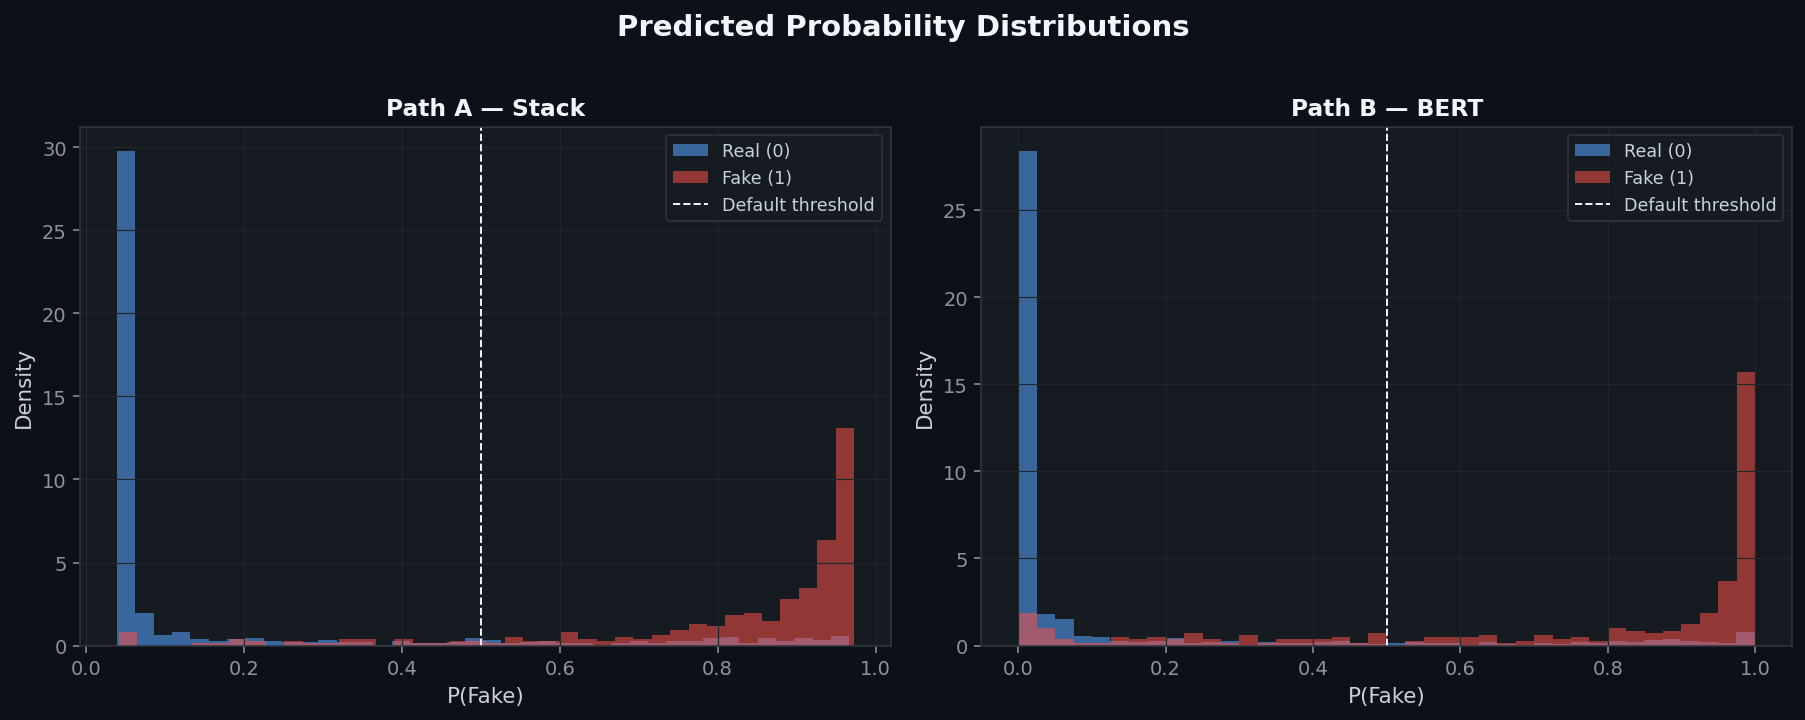

In [25]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))
fig.suptitle('Predicted Probability Distributions', fontsize=15,
             color='#F0F6FC', fontweight='bold', y=1.02)
for ax, probs, label in [
    (axes[0], stack_prob, 'Path A — Stack'),
    (axes[1], bert_prob,  'Path B — BERT'),
]:
    ax.hist(probs[y_test==0], bins=40, density=True,
            color=C_REAL, alpha=0.55, label='Real (0)', edgecolor='none')
    ax.hist(probs[y_test==1], bins=40, density=True,
            color=C_FAKE, alpha=0.55, label='Fake (1)', edgecolor='none')
    ax.axvline(0.5, color='#F0F6FC', lw=1, ls='--', label='Default threshold')
    ax.set_title(label, fontsize=12, color='#F0F6FC', fontweight='bold')
    ax.set_xlabel('P(Fake)')
    ax.set_ylabel('Density')
    ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig('prob_distributions.png', bbox_inches='tight')
plt.show()

## 7.8 Full Metrics Summary Table

In [26]:
rows = [
    full_metrics(y_test, stack_pred, stack_prob, 'Path A — Stack'),
    full_metrics(y_test, bert_pred,  bert_prob,  'Path B — BERT'),
]
summary = pd.DataFrame(rows).set_index('Model').T
fmt = summary.copy()
for col in fmt.columns:
    fmt[col] = fmt[col].apply(lambda x: f'{x:.4f}')
print('\n', '='*60)
print('FULL EVALUATION METRICS SUMMARY')
print('='*60)
print(fmt.to_string())
fmt.to_csv('metrics_summary.csv')
print('\nSaved: metrics_summary.csv')


FULL EVALUATION METRICS SUMMARY
Model          Path A — Stack Path B — BERT
Accuracy               0.8844        0.8645
Macro F1               0.8520        0.8139
Weighted F1            0.8869        0.8628
Fake Precision         0.7332        0.7442
Fake Recall            0.8395        0.6914
Fake F1                0.7827        0.7168
Real Precision         0.9444        0.9005
Real Recall            0.8992        0.9216
Real F1                0.9212        0.9109
Specificity            0.8992        0.9216
Sensitivity            0.8395        0.6914
FPR                    0.1008        0.0784
FNR                    0.1605        0.3086
ROC AUC                0.9486        0.9270
Avg Precision          0.8451        0.8033
Brier Score            0.0892        0.1020
Log Loss               0.2933        0.3646
MCC                    0.7075        0.6286
Cohen's Kappa          0.7045        0.6279

Saved: metrics_summary.csv


## 7.9 Metrics Heatmap

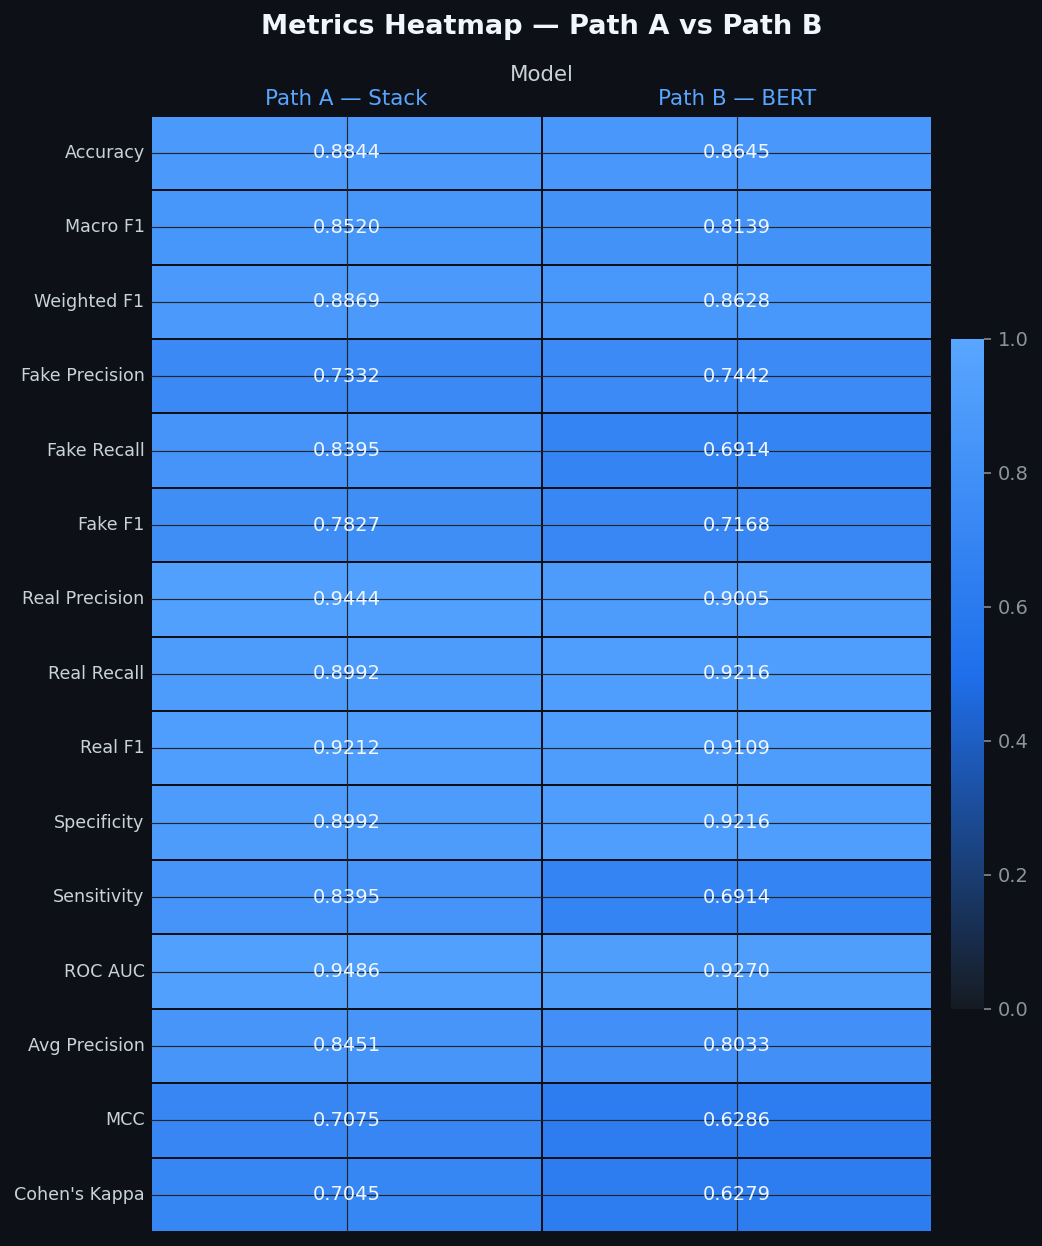

In [27]:
plot_metrics = [
    'Accuracy', 'Macro F1', 'Weighted F1',
    'Fake Precision', 'Fake Recall', 'Fake F1',
    'Real Precision', 'Real Recall', 'Real F1',
    'Specificity', 'Sensitivity',
    'ROC AUC', 'Avg Precision',
    'MCC', "Cohen's Kappa"
]
heat_data = summary.loc[plot_metrics].astype(float)

fig, ax = plt.subplots(figsize=(8, 9))
cmap = LinearSegmentedColormap.from_list('perf', ['#161B22', '#1F6FEB', '#58A6FF'], N=256)
sns.heatmap(
    heat_data, annot=True, fmt='.4f', cmap=cmap,
    linewidths=0.8, linecolor='#0D1117',
    vmin=0, vmax=1, ax=ax,
    annot_kws={'size': 10, 'color': '#F0F6FC'},
    cbar_kws={'shrink': 0.6, 'pad': 0.02}
)
ax.set_title('Metrics Heatmap — Path A vs Path B', fontsize=14,
             fontweight='bold', color='#F0F6FC', pad=16)
ax.tick_params(axis='x', colors='#58A6FF', labelsize=11, length=0)
ax.tick_params(axis='y', colors='#C9D1D9', labelsize=9,  length=0)
ax.collections[0].colorbar.ax.tick_params(colors='#8B949E')
ax.xaxis.set_ticks_position('top')
ax.xaxis.set_label_position('top')
plt.tight_layout()
plt.savefig('metrics_heatmap.png', bbox_inches='tight')
plt.show()

## 7.10 Master Dashboard (all plots in one figure)

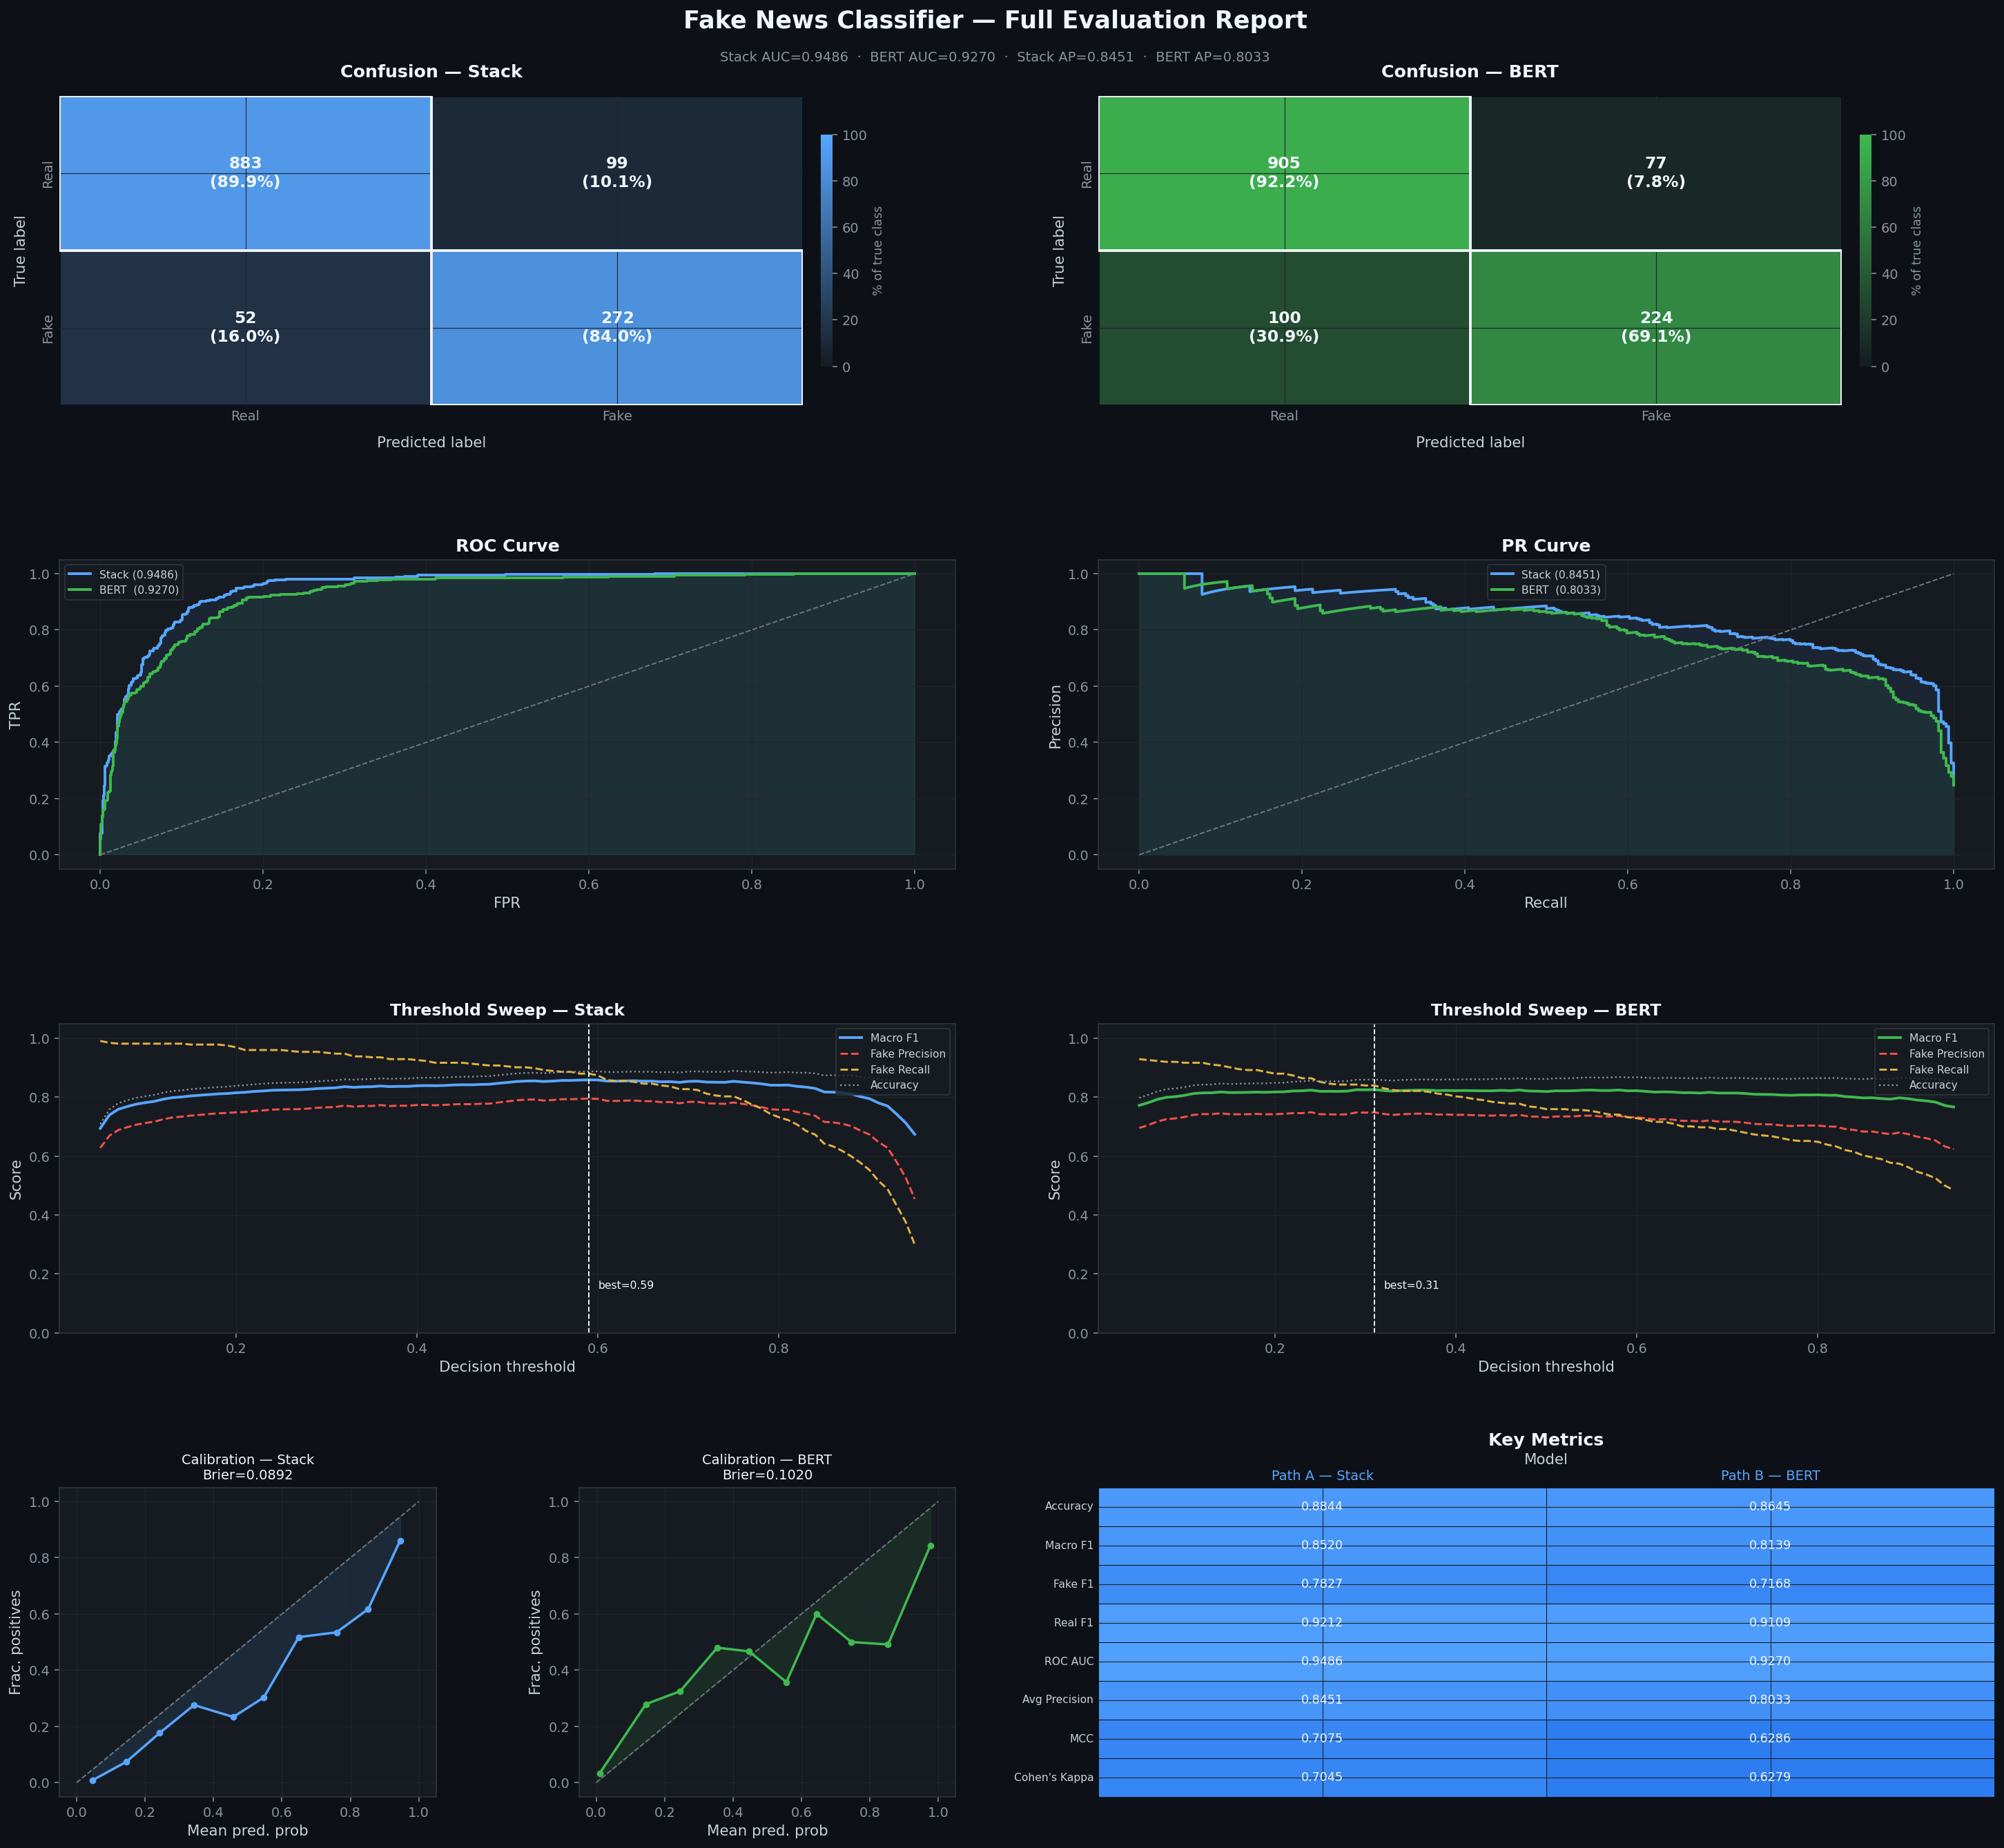

Saved: evaluation_dashboard.png


In [28]:
fig = plt.figure(figsize=(22, 20))
fig.patch.set_facecolor('#0D1117')
gs = gridspec.GridSpec(4, 4, figure=fig, hspace=0.50, wspace=0.38,
                       top=0.93, bottom=0.05, left=0.06, right=0.97)

fig.text(0.5, 0.965, 'Fake News Classifier — Full Evaluation Report',
         ha='center', fontsize=18, fontweight='bold', color='#F0F6FC')
fig.text(0.5, 0.948,
         f'Stack AUC={auc_a:.4f}  ·  BERT AUC={auc_b:.4f}  '
         f'·  Stack AP={ap_a:.4f}  ·  BERT AP={ap_b:.4f}',
         ha='center', fontsize=10, color='#8B949E')

# Row 0: Confusion matrices
plot_confusion(fig.add_subplot(gs[0, :2]), y_test, stack_pred, 'Confusion — Stack', C_STACK)
plot_confusion(fig.add_subplot(gs[0, 2:]), y_test, bert_pred,  'Confusion — BERT',  C_BERT)

# Row 1: ROC + PR
for ax, (xa, ya), (xb, yb), sa, sb, xl, yl, title in [
    (fig.add_subplot(gs[1, :2]),
     (fpr_a, tpr_a), (fpr_b, tpr_b), auc_a, auc_b, 'FPR', 'TPR', 'ROC Curve'),
    (fig.add_subplot(gs[1, 2:]),
     (rec_a, prec_a), (rec_b, prec_b), ap_a, ap_b, 'Recall', 'Precision', 'PR Curve'),
]:
    ax.fill_between(xa, ya, alpha=0.08, color=C_STACK)
    ax.fill_between(xb, yb, alpha=0.08, color=C_BERT)
    ax.plot(xa, ya, color=C_STACK, lw=2, label=f'Stack ({sa:.4f})')
    ax.plot(xb, yb, color=C_BERT,  lw=2, label=f'BERT  ({sb:.4f})')
    ax.plot([0,1],[0,1],'--',color=C_CHANCE,lw=1)
    ax.set_xlabel(xl); ax.set_ylabel(yl)
    ax.set_title(title, color='#F0F6FC', fontweight='bold')
    ax.legend(fontsize=8)

# Row 2: Threshold sweeps
threshold_sweep(y_test, stack_prob, C_STACK, 'Threshold Sweep — Stack', fig.add_subplot(gs[2, :2]))
threshold_sweep(y_test, bert_prob,  C_BERT,  'Threshold Sweep — BERT',  fig.add_subplot(gs[2, 2:]))

# Row 3: Calibration + heatmap
for ax, probs, color, label in [
    (fig.add_subplot(gs[3, 0]), stack_prob, C_STACK, 'Stack'),
    (fig.add_subplot(gs[3, 1]), bert_prob,  C_BERT,  'BERT'),
]:
    fp_, mp_ = calibration_curve(y_test, probs, n_bins=10)
    brier_ = brier_score_loss(y_test, probs)
    ax.plot([0,1],[0,1],'--',color=C_CHANCE,lw=1)
    ax.plot(mp_, fp_, 'o-', color=color, lw=1.8, ms=4)
    ax.fill_between(mp_, fp_, mp_, alpha=0.1, color=color)
    ax.set_title(f'Calibration — {label}\nBrier={brier_:.4f}', color='#F0F6FC', fontsize=10)
    ax.set_xlabel('Mean pred. prob'); ax.set_ylabel('Frac. positives')

ax_heat = fig.add_subplot(gs[3, 2:])
key = ['Accuracy','Macro F1','Fake F1','Real F1','ROC AUC','Avg Precision','MCC',"Cohen's Kappa"]
cmap2 = LinearSegmentedColormap.from_list('perf2', ['#161B22','#1F6FEB','#58A6FF'], N=256)
sns.heatmap(heat_data.loc[key], annot=True, fmt='.4f', cmap=cmap2,
            linewidths=0.5, linecolor='#0D1117', vmin=0, vmax=1, ax=ax_heat,
            annot_kws={'size': 9, 'color': '#F0F6FC'}, cbar=False)
ax_heat.set_title('Key Metrics', color='#F0F6FC', fontweight='bold')
ax_heat.tick_params(axis='x', colors='#58A6FF', labelsize=10, length=0)
ax_heat.tick_params(axis='y', colors='#C9D1D9', labelsize=8,  length=0)
ax_heat.xaxis.set_ticks_position('top')
ax_heat.xaxis.set_label_position('top')

plt.savefig('evaluation_dashboard.png', dpi=150, bbox_inches='tight')
plt.show()
print('Saved: evaluation_dashboard.png')

## 7.11 Classification Reports (Formatted)

In [29]:
for name, y_pred in [('Path A — Stack', stack_pred), ('Path B — BERT', bert_pred)]:
    print(f'\n{"="*52}')
    print(f'  {name}')
    print(f'{"="*52}')
    print(classification_report(y_test, y_pred, target_names=['Real', 'Fake'], digits=4))


  Path A — Stack
              precision    recall  f1-score   support

        Real     0.9444    0.8992    0.9212       982
        Fake     0.7332    0.8395    0.7827       324

    accuracy                         0.8844      1306
   macro avg     0.8388    0.8693    0.8520      1306
weighted avg     0.8920    0.8844    0.8869      1306


  Path B — BERT
              precision    recall  f1-score   support

        Real     0.9005    0.9216    0.9109       982
        Fake     0.7442    0.6914    0.7168       324

    accuracy                         0.8645      1306
   macro avg     0.8223    0.8065    0.8139      1306
weighted avg     0.8617    0.8645    0.8628      1306



## 7.12 Export All Plots as ZIP

In [30]:
plots = [
    'confusion_matrices.png', 'roc_curves.png', 'pr_curves.png',
    'threshold_sweep.png', 'calibration_curves.png', 'prob_distributions.png',
    'metrics_heatmap.png', 'evaluation_dashboard.png', 'metrics_summary.csv',
]
with zipfile.ZipFile('evaluation_report.zip', 'w') as zf:
    for f in plots:
        if os.path.exists(f):
            zf.write(f)
            print(f'  + {f}')
print('\nPacked into: evaluation_report.zip')

  + confusion_matrices.png
  + roc_curves.png
  + pr_curves.png
  + threshold_sweep.png
  + calibration_curves.png
  + prob_distributions.png
  + metrics_heatmap.png
  + evaluation_dashboard.png
  + metrics_summary.csv

Packed into: evaluation_report.zip


---
# 8. Inference — Single Input → Two Outputs

In [31]:
def predict(text: str) -> dict:
    """
    Single input → two independent outputs:
      Output A: Stacked model (LR + RF + SVM)
      Output B: BERT
    """
    clean_text = re.sub(r'[^a-zA-Z ]', ' ', text.lower())
    clean_text = re.sub(r'\s+', ' ', clean_text).strip()

    # PATH A
    vec     = tfidf.transform([clean_text])
    p_lr    = lr.predict_proba(vec)[0, 1]
    p_rf    = rf.predict_proba(vec)[0, 1]
    p_svm   = svm.predict_proba(vec)[0, 1]
    p_stack = meta_stack.predict_proba([[p_lr, p_rf, p_svm]])[0, 1]
    out_a   = 'FAKE' if p_stack >= best_thresh_a else 'REAL'

    # PATH B
    enc = tokenizer([clean_text], padding=True, truncation=True,
                    max_length=MAX_LEN, return_tensors='pt').to(DEVICE)
    with torch.no_grad():
        emb = bert(**enc).last_hidden_state[:, 0, :].cpu().numpy()
    p_bert = bert_clf.predict_proba(emb)[0, 1]
    out_b  = 'FAKE' if p_bert >= best_thresh_b else 'REAL'

    return {
        'Output A — Stack': {
            'LR prob'   : round(p_lr,    3),
            'RF prob'   : round(p_rf,    3),
            'SVM prob'  : round(p_svm,   3),
            'Final prob': round(p_stack, 3),
            'Threshold' : round(best_thresh_a, 2),
            'Prediction': out_a,
        },
        'Output B — BERT': {
            'BERT prob' : round(p_bert, 3),
            'Threshold' : round(best_thresh_b, 2),
            'Prediction': out_b,
        }
    }


sample = 'Scientists confirm that drinking water cures all known diseases'
result = predict(sample)
print(f'Input: "{sample}"\n')
for path, details in result.items():
    print(path)
    for k, v in details.items():
        print(f'  {k}: {v}')
    print()

Input: "Scientists confirm that drinking water cures all known diseases"

Output A — Stack
  LR prob: 0.702
  RF prob: 0.718
  SVM prob: 0.795
  Final prob: 0.837
  Threshold: 0.67
  Prediction: FAKE

Output B — BERT
  BERT prob: 0.18
  Threshold: 0.7
  Prediction: REAL

